# Regression on Acoustic Emotion Data

We use the **EmoSounds** and **IADSED** datasets to predict **arousal** and **valence** from acoustic features.

Steps: clean the data, make a visualization, preprocess and save the data, hold out 20% for testing, use 5-fold cross validation on the remaining 80%, and compare three regression models before and after feature selection.

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

SEED = 42

## 2. Load and clean the data

We check missing values and duplicates. For cleaning, duplicate rows are removed from both datasets and rows with missing values are removed from IADSED.

In [2]:
emo = pd.read_csv('EmoSounds-3.csv')
iad = pd.read_csv('IADSED-2.csv')

print('EmoSounds shape:', emo.shape)
print('IADSED shape:', iad.shape)
print('EmoSounds missing values:', emo.isna().sum().sum())
print('IADSED missing values:', iad.isna().sum().sum())
print('EmoSounds duplicate rows:', emo.duplicated().sum())
print('IADSED duplicate rows:', iad.duplicated().sum())

EmoSounds shape: (600, 75)
IADSED shape: (935, 76)
EmoSounds missing values: 0
IADSED missing values: 27
EmoSounds duplicate rows: 0
IADSED duplicate rows: 0


In [3]:
emo_clean = emo.drop_duplicates().copy()
iad_clean = iad.drop_duplicates().dropna().copy()

print('EmoSounds after cleaning:', emo_clean.shape)
print('IADSED after cleaning:', iad_clean.shape)

EmoSounds after cleaning: (600, 75)
IADSED after cleaning: (927, 76)


## 3. Visualization

Arousal and valence are the two prediction targets. The scatter plots give a quick view of how they relate in each dataset.

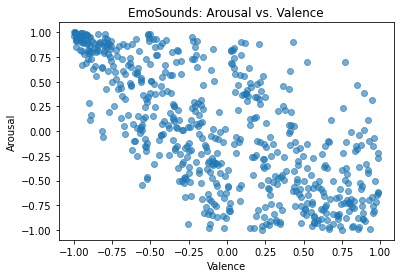

In [4]:
plt.figure(figsize=(6, 4))
plt.scatter(emo_clean['valence'], emo_clean['arousal'], alpha=0.6)
plt.xlabel('Valence')
plt.ylabel('Arousal')
plt.title('EmoSounds: Arousal vs. Valence')
plt.show()

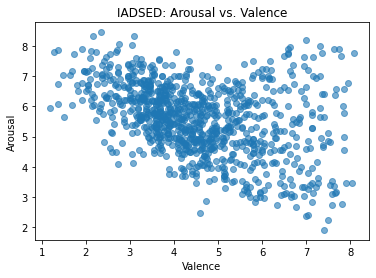

In [5]:
plt.figure(figsize=(6, 4))
plt.scatter(iad_clean['valence'], iad_clean['arousal'], alpha=0.6)
plt.xlabel('Valence')
plt.ylabel('Arousal')
plt.title('IADSED: Arousal vs. Valence')
plt.show()

The relationship is negative in both datasets: samples with larger valence values tend to have smaller arousal values. The relationship is stronger in EmoSounds than in IADSED.

## 4. Preprocessing

The models should use acoustic features, not file names or text labels. We remove metadata columns, remove `dominance` from IADSED, keep numeric columns, and remove constant features.

Scaling is done later inside the model pipeline so it is fit only on training data during cross validation.

In [6]:
targets = ['arousal', 'valence']

emo_metadata = ['dataset', 'fnames', 'genre', 'splits', 'vocals']
iad_metadata = ['source', 'description', 'category', 'fname', 'BE_Classification', 'dominance']

emo_preprocessed = emo_clean.drop(columns=emo_metadata).select_dtypes(include=np.number)
iad_preprocessed = iad_clean.drop(columns=iad_metadata).select_dtypes(include=np.number)

emo_constant = [c for c in emo_preprocessed.columns if emo_preprocessed[c].nunique() <= 1]
iad_constant = [c for c in iad_preprocessed.columns if iad_preprocessed[c].nunique() <= 1]

emo_preprocessed = emo_preprocessed.drop(columns=emo_constant)
iad_preprocessed = iad_preprocessed.drop(columns=iad_constant)

emo_features = [c for c in emo_preprocessed.columns if c not in targets]
iad_features = [c for c in iad_preprocessed.columns if c not in targets]

print('EmoSounds features:', len(emo_features))
print('IADSED features:', len(iad_features))

EmoSounds features: 68
IADSED features: 68


In [7]:
emo_preprocessed.to_csv('EmoSounds_preprocessed.csv', index=False)
iad_preprocessed.to_csv('IADSED_preprocessed.csv', index=False)

print('Saved EmoSounds_preprocessed.csv')
print('Saved IADSED_preprocessed.csv')

Saved EmoSounds_preprocessed.csv
Saved IADSED_preprocessed.csv


## 5. Train / validation / test split

We first hold out 20% as the final test set. The remaining 80% is the train + validation pool used for 5-fold cross validation.

The separate 60% train and 20% validation sets are shown only to verify the required 60:20:20 split. Hyperparameter tuning uses the full 80% train + validation pool, as required by the project.

In [8]:
def split_dataset(df):
    train_val, test = train_test_split(
        df, test_size=0.20, random_state=SEED, shuffle=True
    )
    train, val = train_test_split(
        train_val, test_size=0.25, random_state=SEED, shuffle=True
    )
    return train, val, train_val, test

emo_train, emo_val, emo_train_val, emo_test = split_dataset(emo_preprocessed)
iad_train, iad_val, iad_train_val, iad_test = split_dataset(iad_preprocessed)

split_sizes = pd.DataFrame({
    'Dataset': ['EmoSounds', 'IADSED'],
    'Train (60%)': [len(emo_train), len(iad_train)],
    'Validation (20%)': [len(emo_val), len(iad_val)],
    'Test (20%)': [len(emo_test), len(iad_test)]
})
split_sizes

,Dataset,Train (60%),Validation (20%),Test (20%)
0,EmoSounds,360,120,120
1,IADSED,555,186,186


## 6. Models and metric

We compare three regression models with increasing complexity:

- **Linear Regression**
- **Decision Tree Regression**
- **Random Forest Regression**

We use **RMSE**. Lower RMSE is better.

In [9]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

models = {
    'Linear Regression': {
        'model': LinearRegression(),
        'scale': True,
        'params': {'model__fit_intercept': [True, False]}
    },
    'Decision Tree': {
        'model': DecisionTreeRegressor(random_state=SEED),
        'scale': False,
        'params': {
            'model__max_depth': [5, None],
            'model__min_samples_leaf': [1, 3]
        }
    },
    'Random Forest': {
        'model': RandomForestRegressor(n_estimators=50, random_state=SEED, n_jobs=-1),
        'scale': False,
        'params': {
            'model__max_depth': [5, None],
            'model__min_samples_leaf': [1, 3]
        }
    }
}

cv = KFold(n_splits=5, shuffle=True, random_state=SEED)

## 7. Cross validation and hyperparameter tuning

For each model, `GridSearchCV` uses 5-fold cross validation on the 80% train + validation pool. After choosing the best hyperparameters, the best model is retrained on that full 80% pool and evaluated once on the held-out test set.

In [10]:
def fit_and_evaluate(X_train_val, y_train_val, X_test, y_test, model_name, use_fs=False):
    spec = models[model_name]
    steps = []

    if use_fs:
        steps.append(('select', SelectKBest(score_func=f_regression, k=20)))
    if spec['scale']:
        steps.append(('scale', StandardScaler()))

    steps.append(('model', clone(spec['model'])))
    pipe = Pipeline(steps)

    search = GridSearchCV(
        pipe,
        spec['params'],
        scoring='neg_root_mean_squared_error',
        cv=cv,
        n_jobs=1,
        refit=True
    )
    search.fit(X_train_val, y_train_val)

    train_pred = search.predict(X_train_val)
    test_pred = search.predict(X_test)

    return {
        'model': model_name,
        'features': 'Top 20' if use_fs else 'All',
        'cv_rmse': -search.best_score_,
        'train_rmse': rmse(y_train_val, train_pred),
        'test_rmse': rmse(y_test, test_pred),
        'best_params': search.best_params_
    }

## 8. Train models without feature selection

In [11]:
datasets = {
    'EmoSounds': (emo_train_val, emo_test, emo_features),
    'IADSED': (iad_train_val, iad_test, iad_features)
}

results = []

for dataset_name, (train_val, test, features) in datasets.items():
    for target in targets:
        X_train_val = train_val[features]
        y_train_val = train_val[target]
        X_test = test[features]
        y_test = test[target]

        for model_name in models:
            row = fit_and_evaluate(
                X_train_val, y_train_val, X_test, y_test,
                model_name, use_fs=False
            )
            row['dataset'] = dataset_name
            row['target'] = target
            results.append(row)

## 9. Feature selection

We repeat the same tuning procedure after selecting the **20 acoustic features with the largest F-regression scores**. The selector is inside the pipeline, before the model, so it is fit separately in each cross-validation fold.

In [12]:
for dataset_name, (train_val, test, features) in datasets.items():
    for target in targets:
        X_train_val = train_val[features]
        y_train_val = train_val[target]
        X_test = test[features]
        y_test = test[target]

        for model_name in models:
            row = fit_and_evaluate(
                X_train_val, y_train_val, X_test, y_test,
                model_name, use_fs=True
            )
            row['dataset'] = dataset_name
            row['target'] = target
            results.append(row)

## 10. Results

`train_rmse` is measured on the final 80% train + validation pool after the best hyperparameters are selected. `test_rmse` is measured once on the held-out 20% test set.

In [13]:
results_df = pd.DataFrame(results)
results_df = results_df[
    ['dataset', 'target', 'model', 'features', 'cv_rmse', 'train_rmse', 'test_rmse', 'best_params']
]
results_df.round(4)

,dataset,target,model,features,cv_rmse,train_rmse,test_rmse,best_params
0,EmoSounds,arousal,Linear Regression,All,0.3335,0.2441,0.2366,{'model__fit_intercept': True}
1,EmoSounds,arousal,Decision Tree,All,0.3273,0.1763,0.2550,"{'model__max_depth': 5, 'model__min_samples_le..."
2,EmoSounds,arousal,Random Forest,All,0.2461,0.0902,0.2106,"{'model__max_depth': None, 'model__min_samples..."
3,EmoSounds,valence,Linear Regression,All,0.3903,0.3262,0.4462,{'model__fit_intercept': True}
4,EmoSounds,valence,Decision Tree,All,0.4401,0.2784,0.3982,"{'model__max_depth': 5, 'model__min_samples_le..."
5,EmoSounds,valence,Random Forest,All,0.3614,0.1389,0.3828,"{'model__max_depth': None, 'model__min_samples..."
6,IADSED,arousal,Linear Regression,All,0.9169,0.7681,0.8422,{'model__fit_intercept': True}
7,IADSED,arousal,Decision Tree,All,0.9795,0.7024,0.9040,"{'model__max_depth': 5, 'model__min_samples_le..."
8,IADSED,arousal,Random Forest,All,0.8058,0.3133,0.7138,"{'model__max_depth': None, 'model__min_samples..."
9,IADSED,valence,Linear Regression,All,1.2039,1.0698,1.2128,{'model__fit_intercept': True}


### Before vs. after feature selection

In [14]:
comparison = results_df.pivot_table(
    index=['dataset', 'target', 'model'],
    columns='features',
    values=['train_rmse', 'test_rmse']
)
comparison.round(4)

test_rmse         train_rmse        
features                                  All  Top 20        All  Top 20
dataset   target  model                                                 
EmoSounds arousal Decision Tree        0.2550  0.2729     0.1763  0.1926
                  Linear Regression    0.2366  0.2828     0.2441  0.2918
                  Random Forest        0.2106  0.2258     0.0902  0.0904
          valence Decision Tree        0.3982  0.4799     0.2784  0.3109
                  Linear Regression    0.4462  0.4545     0.3262  0.3929
                  Random Forest        0.3828  0.4220     0.1389  0.1912
IADSED    arousal Decision Tree        0.9040  0.8731     0.7024  0.7162
                  Linear Regression    0.8422  0.8494     0.7681  0.8404
                  Random Forest        0.7138  0.7380     0.3133  0.3019
          valence Decision Tree        1.2610  1.2145     0.9550  0.9811
                  Linear Regression    1.2128  1.2396     1.0698  1.1546
                  Random Forest        1.1301  1.1438     0.5153  0.5539

## 11. Conclusion

Use the results table to compare:

- cross-validation RMSE used for tuning,
- train RMSE versus test RMSE,
- the three regression models,
- and performance with all features versus the top 20 selected features.

A much smaller train RMSE than test RMSE is evidence of overfitting. The best model for each dataset and target is the one with the lowest held-out test RMSE after tuning.